### Scatter plots comparing Reservoir Volume vs Pearson Correlation

In [22]:
import pandas as pd
from scipy.stats import pearsonr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns
from matplotlib.lines import Line2D
from scipy import stats
import numpy as np


# Set publication-quality style parameters
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Helvetica', 'Liberation Sans', 'Bitstream Vera Sans', 'sans-serif'],
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 300,
    'savefig.dpi': 600
})

In [2]:
hybrid_model_data_all_variables = pd.read_csv("/scratch/shah0012/hybrid_hydropower_model/data/hybrid_model_data/hybrid_model_train_generation_data_1981_2022_selected_variables_snow_cover_historical_plant_lat.csv", parse_dates=['date'])
hybrid_model_data_all_variables["Month"] = hybrid_model_data_all_variables.date.dt.month
hybrid_model_data_all_variables = hybrid_model_data_all_variables[["glohydrores_plant_id", "physical_hydropower_0n", "date", "observed_generation_mw", "installed_capacity_mw", "Month"]]


In [11]:
# --- Map plant metadata and perform spatial join for all models ---
GloHydroRes = pd.read_excel("/home/shah0012/GloHydroRes/Output_data/GloHydroRes_vs2.xlsx", sheet_name="Data")

In [8]:
def load_model_results(base_path, file_name):
    """
    Loads model test results from a CSV file and adds a 'Model' column.

    Args:
        base_path (str): The base directory path for the file.
        file_name (str): The name of the CSV file.

    Returns:
        pd.DataFrame: The loaded and processed DataFrame.

    Raises:
        ValueError: If base_path is not a string or file_name does not end with .csv.
    """
    if not isinstance(base_path, str):
        raise ValueError("base_path must be a string")
    if not file_name.endswith('.csv'):
        raise ValueError(f"File {file_name} does not have a .csv extension")
    
    print(f"Loading file: {base_path + file_name}")
    model_test_result = pd.read_csv(base_path + file_name)
    words = file_name.split("_")[0:2]
    model_name = ' '.join(word.capitalize() for word in words)
    model_test_result["Model"] = model_name
    return model_test_result
    

def process_model_results(base_path, file_name, main_data):
    """
    Loads, merges, and filters model results for plants with more than 24 months of data.
    Returns the filtered DataFrame.
    """
    df = load_model_results(base_path, file_name)
    df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d")
    df = df.merge(main_data[["glohydrores_plant_id", "date", "physical_hydropower_0n", "observed_generation_mw"]], on=["glohydrores_plant_id", "date"], how="left")
    return df

def map_plant_metadata(df, GloHydroRes):
    """
    Maps plant metadata columns to the DataFrame.
    """
    df["plant_lat"] = df["glohydrores_plant_id"].map(dict(zip(GloHydroRes.ID, GloHydroRes.plant_lat)))
    df["plant_lon"] = df["glohydrores_plant_id"].map(dict(zip(GloHydroRes.ID, GloHydroRes.plant_lon)))
    df["country"] = df["glohydrores_plant_id"].map(dict(zip(GloHydroRes.ID, GloHydroRes.country)))
    df["plant_type"] = df["glohydrores_plant_id"].map(dict(zip(GloHydroRes.ID, GloHydroRes.plant_type)))
    df["instaled_capacity"] = df["glohydrores_plant_id"].map(dict(zip(GloHydroRes.ID, GloHydroRes.capacity_mw)))
    return df


# --- Process all models using the utility functions ---
model_files = {
    'RF': "rf_test_result_designed_split_target_cf.csv",
    'XGB': "xgb_test_result_designed_split_target_cf.csv",
    'MLR': "lr_test_result_designed_split_target_CF.csv",
    'MLP': "mlp_test_result_designed_split_target_CF.csv"}


model_results = {}
for model, file_name in model_files.items():
    model_results[model] = process_model_results(
        "/scratch/shah0012/hybrid_hydropower_model/hybrid_model_results/",
        file_name,
        hybrid_model_data_all_variables
    )



Loading file: /scratch/shah0012/hybrid_hydropower_model/hybrid_model_results/rf_test_result_designed_split_target_cf.csv
Loading file: /scratch/shah0012/hybrid_hydropower_model/hybrid_model_results/xgb_test_result_designed_split_target_cf.csv
Loading file: /scratch/shah0012/hybrid_hydropower_model/hybrid_model_results/lr_test_result_designed_split_target_CF.csv
Loading file: /scratch/shah0012/hybrid_hydropower_model/hybrid_model_results/mlp_test_result_designed_split_target_CF.csv


#### Calculate Pearson Correlation

In [9]:
def compute_pearson_hybrid(group):
    """
    Computes the Pearson correlation coefficient between observed and predicted hybrid generation.
    Returns NaN if there isn't enough data or if standard deviation is zero.
    """
    if len(group) < 2 or group["observed_generation_mw"].std() == 0 or group["originial_prediction"].std() == 0:
        return pd.Series({"pearson_hybrid": np.nan})
    pearson_corr, _ = pearsonr(group["observed_generation_mw"], group["originial_prediction"])
    return pd.Series({"pearson_hybrid": pearson_corr})

def compute_pearson_physical(group):
    """
    Computes the Pearson correlation coefficient between observed and physical model generation.
    Returns NaN if there isn't enough data or if standard deviation is zero.
    """
    if len(group) < 2 or group["observed_generation_mw"].std() == 0 or group["physical_hydropower_0n"].std() == 0:
        return pd.Series({"pearson_physical": np.nan})
    pearson_corr, _ = pearsonr(group["observed_generation_mw"], group["physical_hydropower_0n"])
    return pd.Series({"pearson_physical": pearson_corr})

# Calculate Pearson correlation by plant for all models
def compute_pearson_by_plant(df):
    pearson_hybrid = df.groupby("glohydrores_plant_id").apply(compute_pearson_hybrid)
    pearson_physical = df.groupby("glohydrores_plant_id").apply(compute_pearson_physical)
    pearson_hybrid.reset_index(inplace=True)
    pearson_physical.reset_index(inplace=True)
    return pearson_hybrid.merge(pearson_physical, on="glohydrores_plant_id", how="left")


In [12]:
pearson_dfs = {}
for model, df in model_results.items():
    print(model)
    pearson_df = compute_pearson_by_plant(df)
    pearson_df = map_plant_metadata(pearson_df, GloHydroRes)
    pearson_dfs[model] = pearson_df

RF
XGB
MLR
MLP


#### Scatter Plots

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
from matplotlib.lines import Line2D
from scipy import stats
import numpy as np

model_name = "RF"

def plot_pearson_by_plant_type(pearson_dfs, model_name, col_name, ylabel, model_type):
    model_pearson_dfs = pearson_dfs[model_name]
    model_pearson_dfs["res_vol"] = model_pearson_dfs["glohydrores_plant_id"].map(dict(zip(GloHydroRes.ID, GloHydroRes.res_vol_km3)))
    model_pearson_dfs["difference_pearson"] = model_pearson_dfs.pearson_hybrid - model_pearson_dfs.pearson_physical
    model_pearson_dfs["is_positive"] = (model_pearson_dfs.difference_pearson > 0).astype(int)
    model_pearson_dfs["plant_type"] = model_pearson_dfs.plant_type.fillna("STO")
    
    # Create color mapping
    unique_types = model_pearson_dfs.plant_type.unique()
    colors = sns.color_palette('tab10', n_colors=len(unique_types))
    color_map = dict(zip(unique_types, colors))

    g = sns.jointplot(data=model_pearson_dfs, x="res_vol", y= col_name, 
                      kind="scatter", height=6, ratio=2)

    g.ax_joint.clear()
    
    # Use installed capacity directly (adjust multiplier as needed)
    bubble_sizes = model_pearson_dfs["instaled_capacity"] * 0.15
    
    # Plot each plant type
    for plant in unique_types:
        mask = model_pearson_dfs.plant_type == plant
        g.ax_joint.scatter(model_pearson_dfs.loc[mask, "res_vol"],
                       model_pearson_dfs.loc[mask, col_name],
                       s=bubble_sizes[mask],
                       c=[color_map[plant]],
                       alpha=0.3,
                       edgecolors="black",
                       linewidths=0.3,
                       label=plant)

    # Create custom legend handles with uniform size
    legend_handles = [Line2D([0], [0], marker='o', color='w', 
                         markerfacecolor=color_map[plant], 
                         markersize=10,
                         alpha=0.6, 
                         markeredgecolor='black', 
                         markeredgewidth=0.5,
                         label=plant) 
                  for plant in unique_types]

    # Remove x marginal histogram
    g.ax_marg_x.set_visible(False)

    # Clear and recreate y marginal plot with density plots for each plant type
    g.ax_marg_y.clear()

    # Add density plots for each plant type on y-axis
    for plant in unique_types:
        mask = model_pearson_dfs.plant_type == plant
        data = model_pearson_dfs.loc[mask, col_name].dropna()
        # Calculate median
        median_val = data.median()
    
        # Calculate KDE
        kde = stats.gaussian_kde(data)
        y_range = np.linspace(-1, 1, 200)
        density = kde(y_range)
        
        # Plot density curve
        g.ax_marg_y.plot(density, y_range,
                     color=color_map[plant],
                     alpha=0.6,
                     linewidth=2)
    
        # Optional: fill under the curve
        g.ax_marg_y.fill_betweenx(y_range, 0, density,
                              color=color_map[plant],
                              alpha=0.3)
    
        # Add median line
        g.ax_marg_y.axhline(y=median_val, 
                        color=color_map[plant],
                        linestyle='--',
                        linewidth=1.5,
                        alpha=0.8)

    # Remove tick labels from marginal plot
    #g.ax_marg_y.set_yticks([])
    g.ax_marg_y.set_xlabel('')
    g.ax_marg_y.set_ylim(-1, 1)  # Match y-axis limits

    # Apply log scale to main plot
    g.ax_joint.set_xscale('log')
    g.ax_joint.set_ylim(-1, 1)
    # Add horizontal line at y=0
    g.ax_joint.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    g.ax_joint.set_xlabel("Reservoir Volume (log scale)", fontsize=14)
    g.ax_joint.set_ylabel(ylabel, fontsize=14)
    g.ax_joint.tick_params(labelsize = 13)

    # Add legend
    g.ax_joint.legend(handles=legend_handles, 
                  title="Plant Type", 
                  loc="upper left",
                  frameon=False,
                  fontsize=10,
                  title_fontsize = 11)

    # Adjust figure DPI
    g.fig.set_dpi(300)

    plt.tight_layout()

    # Save figure
    g.savefig(f'/home/shah0012/Hydropower_hybrid_model/figures/{model_type}_reservoir_correlation.pdf', 
         dpi=300, bbox_inches='tight')

    plt.show()

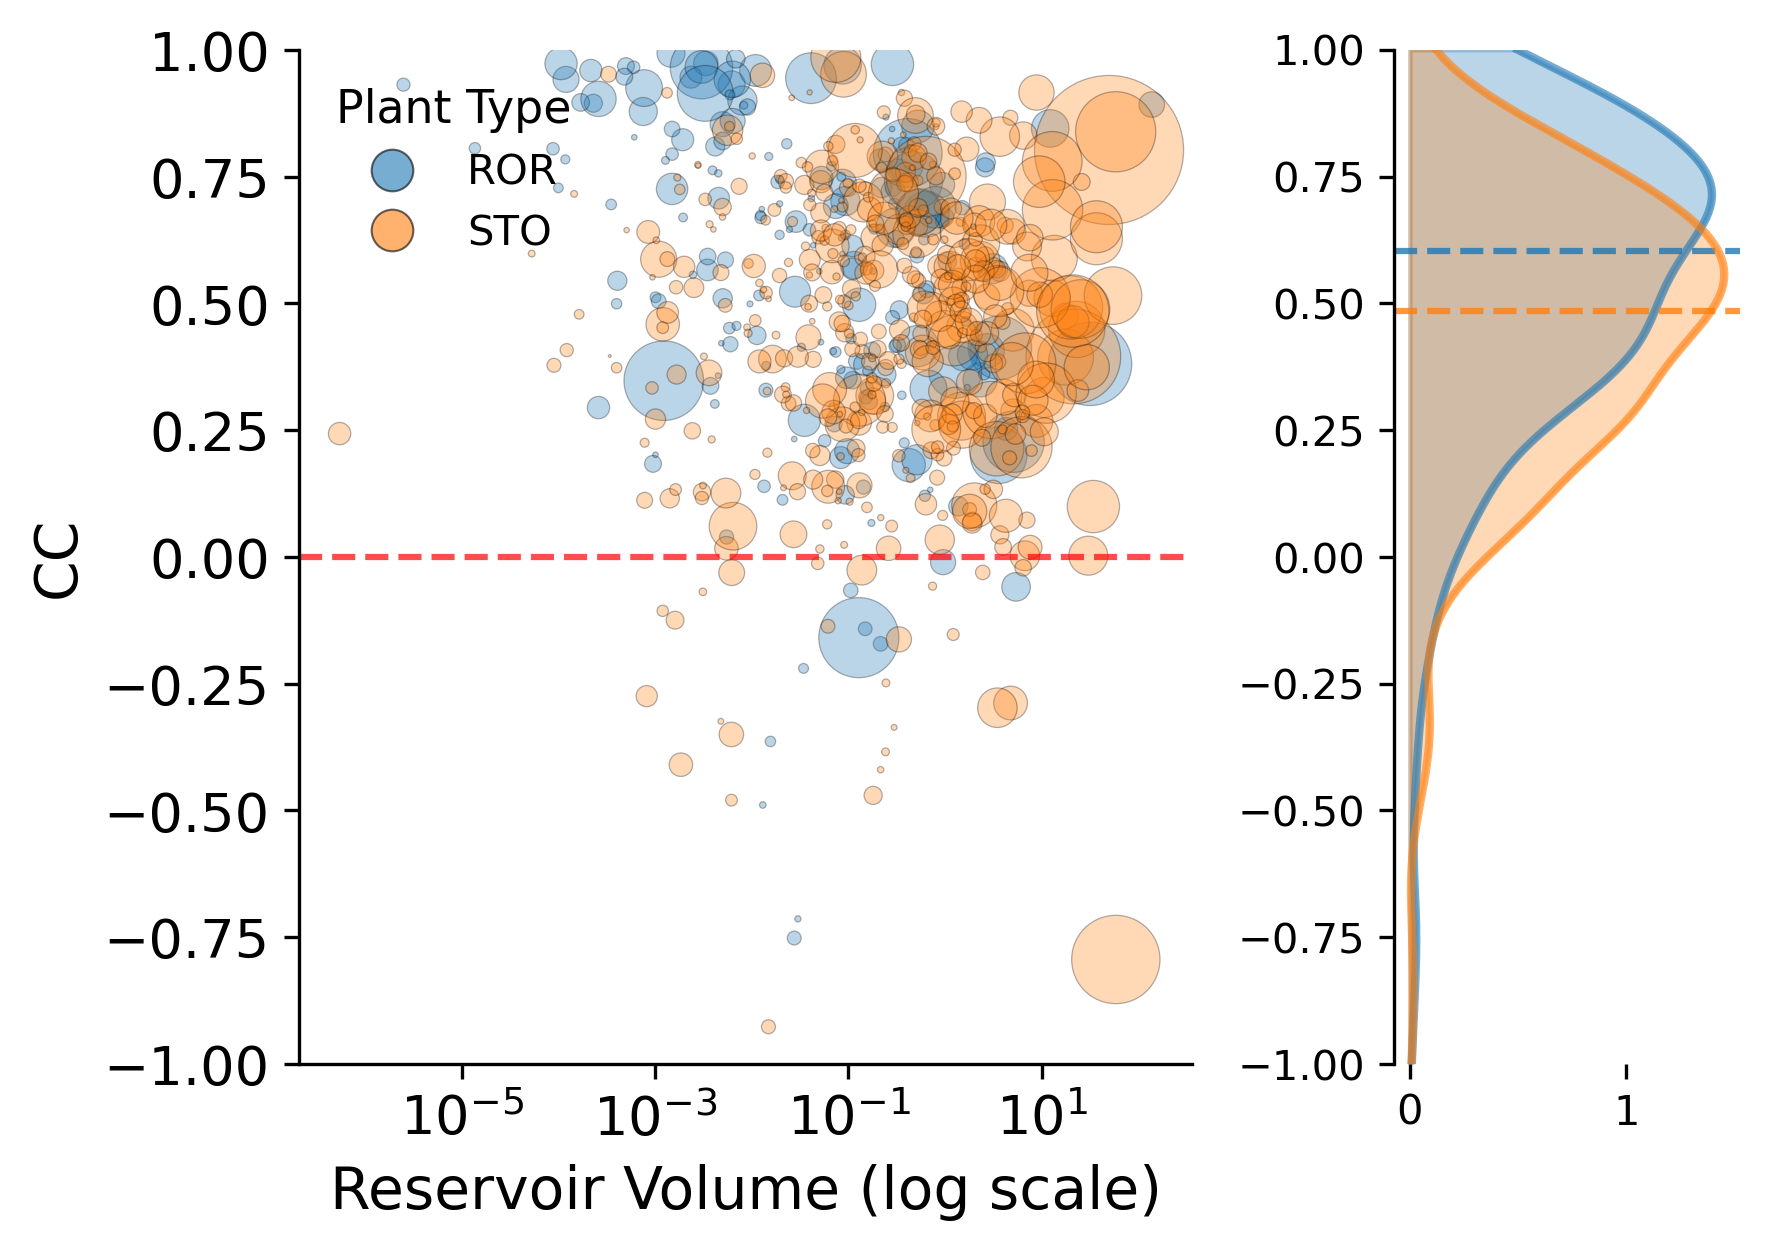

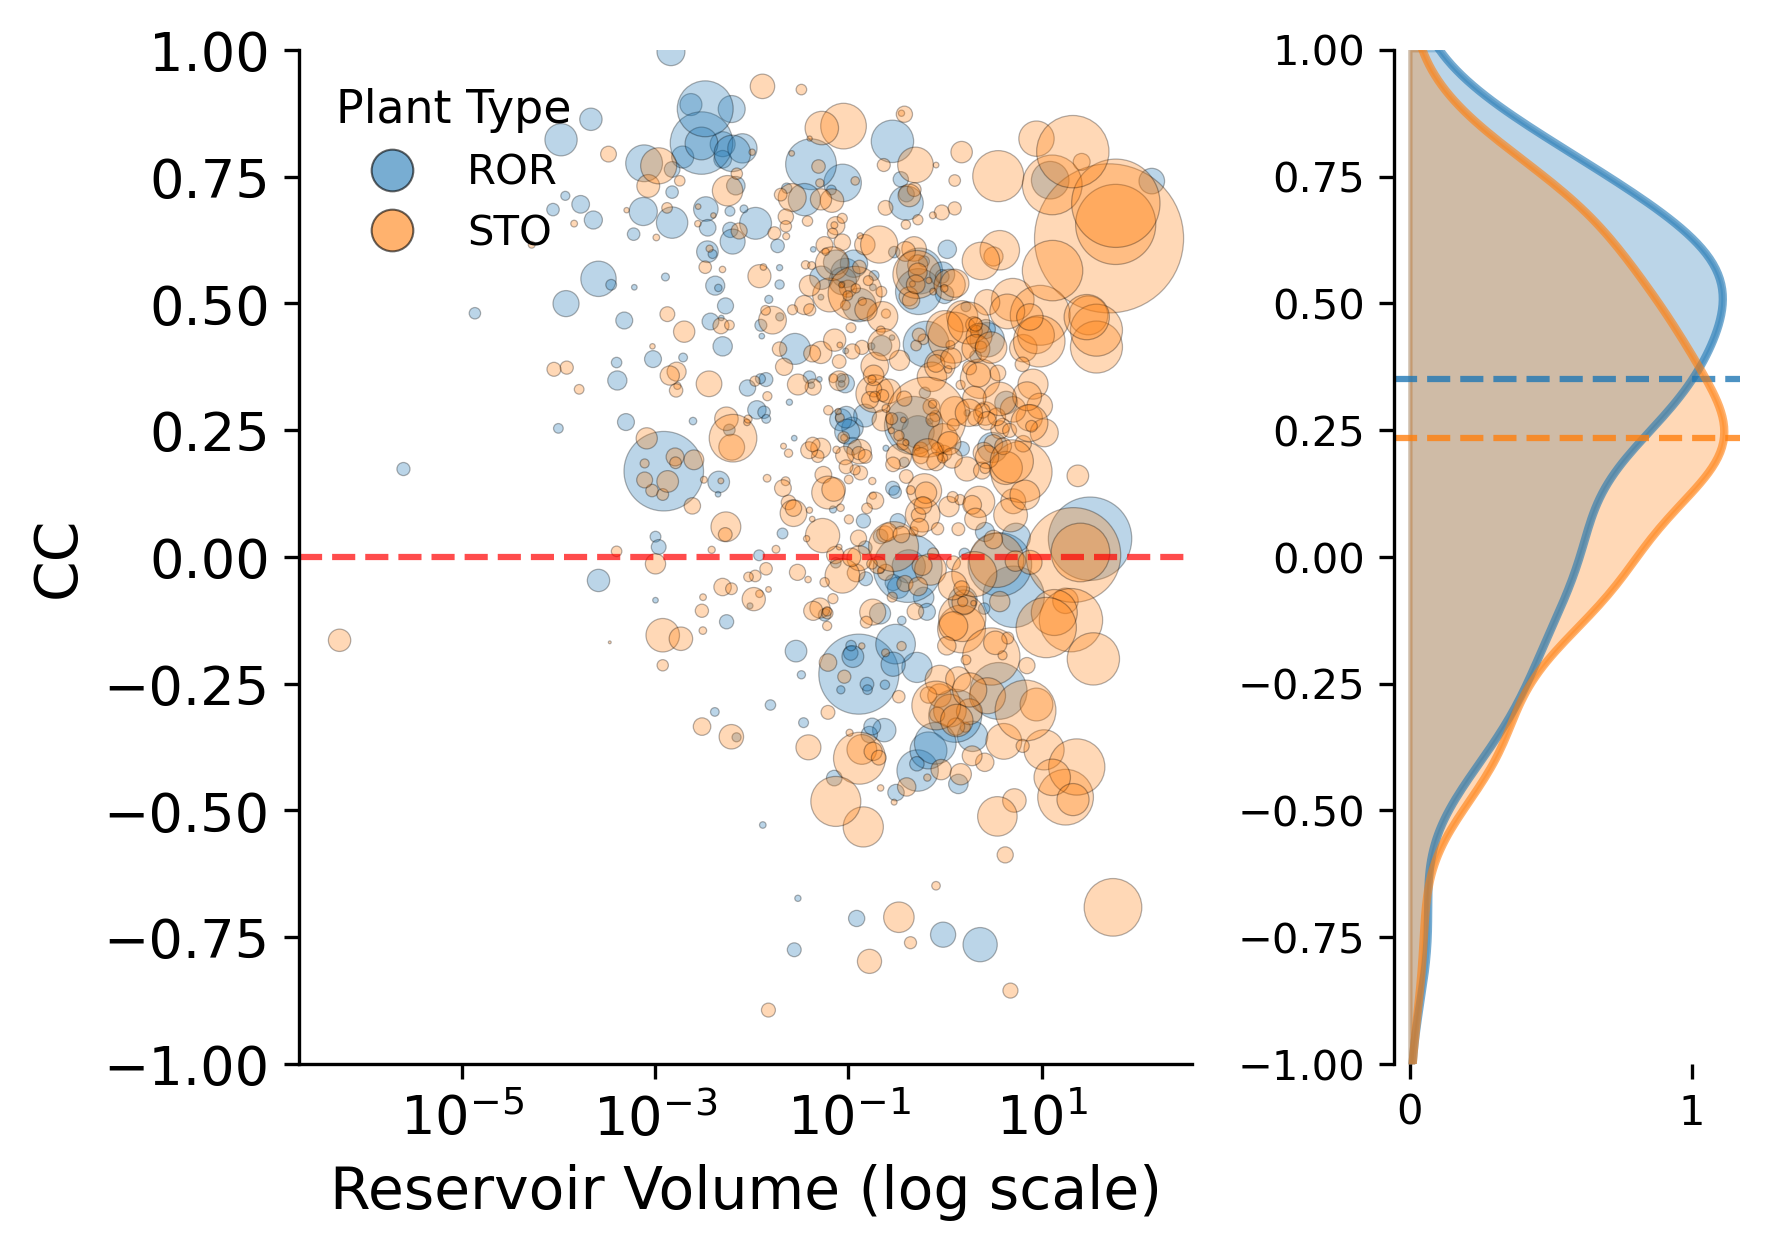

In [16]:
plot_pearson_by_plant_type(pearson_dfs, "RF", "pearson_hybrid", "CC", "RF")
plot_pearson_by_plant_type(pearson_dfs, "RF", "pearson_physical", "CC", "Physical")

#### Hydropower plants: Example time series plots

In [17]:
rf_hybrid_file = "/scratch/shah0012/hybrid_hydropower_model/hybrid_model_results/rf_test_result_designed_split_target_cf.csv"
rf_hybrid_data = pd.read_csv(rf_hybrid_file, parse_dates = ["date"])
rf_hybrid_data["observed_mw"] = rf_hybrid_data.observed_plant_CF * rf_hybrid_data.installed_capacity_mw

rf_hybrid_data = rf_hybrid_data.merge(hybrid_model_data_all_variables[["date", "glohydrores_plant_id", "physical_hydropower_0n"]], on = ["date", "glohydrores_plant_id"], how = "left")

In [28]:
def timeseries_plot(plant_ID, text_limit, lower_range_yticks, upper_range_yticks, diff):
        plant_country = GloHydroRes[GloHydroRes.ID ==plant_ID].country.iloc[0]
        plant_name = GloHydroRes[GloHydroRes.ID == plant_ID].name.iloc[0]
        plant_capacity = GloHydroRes[GloHydroRes.ID == plant_ID].capacity_mw.iloc[0]
        plant_reservoir = GloHydroRes[GloHydroRes.ID == plant_ID].res_vol_km3.iloc[0]
        
        # Filter data for the specific plant
        plant_data = rf_hybrid_data[rf_hybrid_data.glohydrores_plant_id == plant_ID]
        
        # Create figure with high DPI
        fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
        
        # Plot all three time series
        ax.plot(plant_data["date"], plant_data["originial_prediction"], label='Hybrid (RF)', linewidth=1.5, alpha=0.8, color='#1f77b4')
        ax.plot(plant_data["date"], plant_data["physical_hydropower_0n"], label='Hydropower Potential', linewidth=1.5, alpha=0.8, color='#ff7f0e')
        ax.plot(plant_data["date"], plant_data["observed_mw"],  label='Observed', linewidth=2, alpha=0.9, color='black', linestyle='--')
        
        # Formatting
        ax.set_xlabel('Date', fontsize=14)
        ax.set_ylabel('Power Output (MW)', fontsize=14)

        # Legend
        ax.legend(loc='best', fontsize=12, frameon=False, shadow=True)

        # Grid
        ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

        ax.text(plant_data["date"].min(), plant_data[["originial_prediction", "physical_hydropower_0n", "observed_mw"]].max().max() + text_limit, f'IC - {plant_capacity} MW, RV - {plant_reservoir.round(2)} KM3', fontsize = 15)

        # Format x-axis dates
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=5))
        ax.set_yticks(ticks = np.arange(lower_range_yticks, upper_range_yticks, diff))
        #ax.set_yticks(ticks = np.arange(20, 160, 20))
        plt.xticks(rotation=45, ha='right')
        ax.tick_params(labelsize = 13)
        
        # Tight layout
        plt.tight_layout()
        
        # Save in multiple formats
        plt.savefig(f'/home/shah0012/Hydropower_hybrid_model/figures/hydropower_comparison_{plant_ID}.pdf', dpi=300, bbox_inches='tight')

        plt.show()

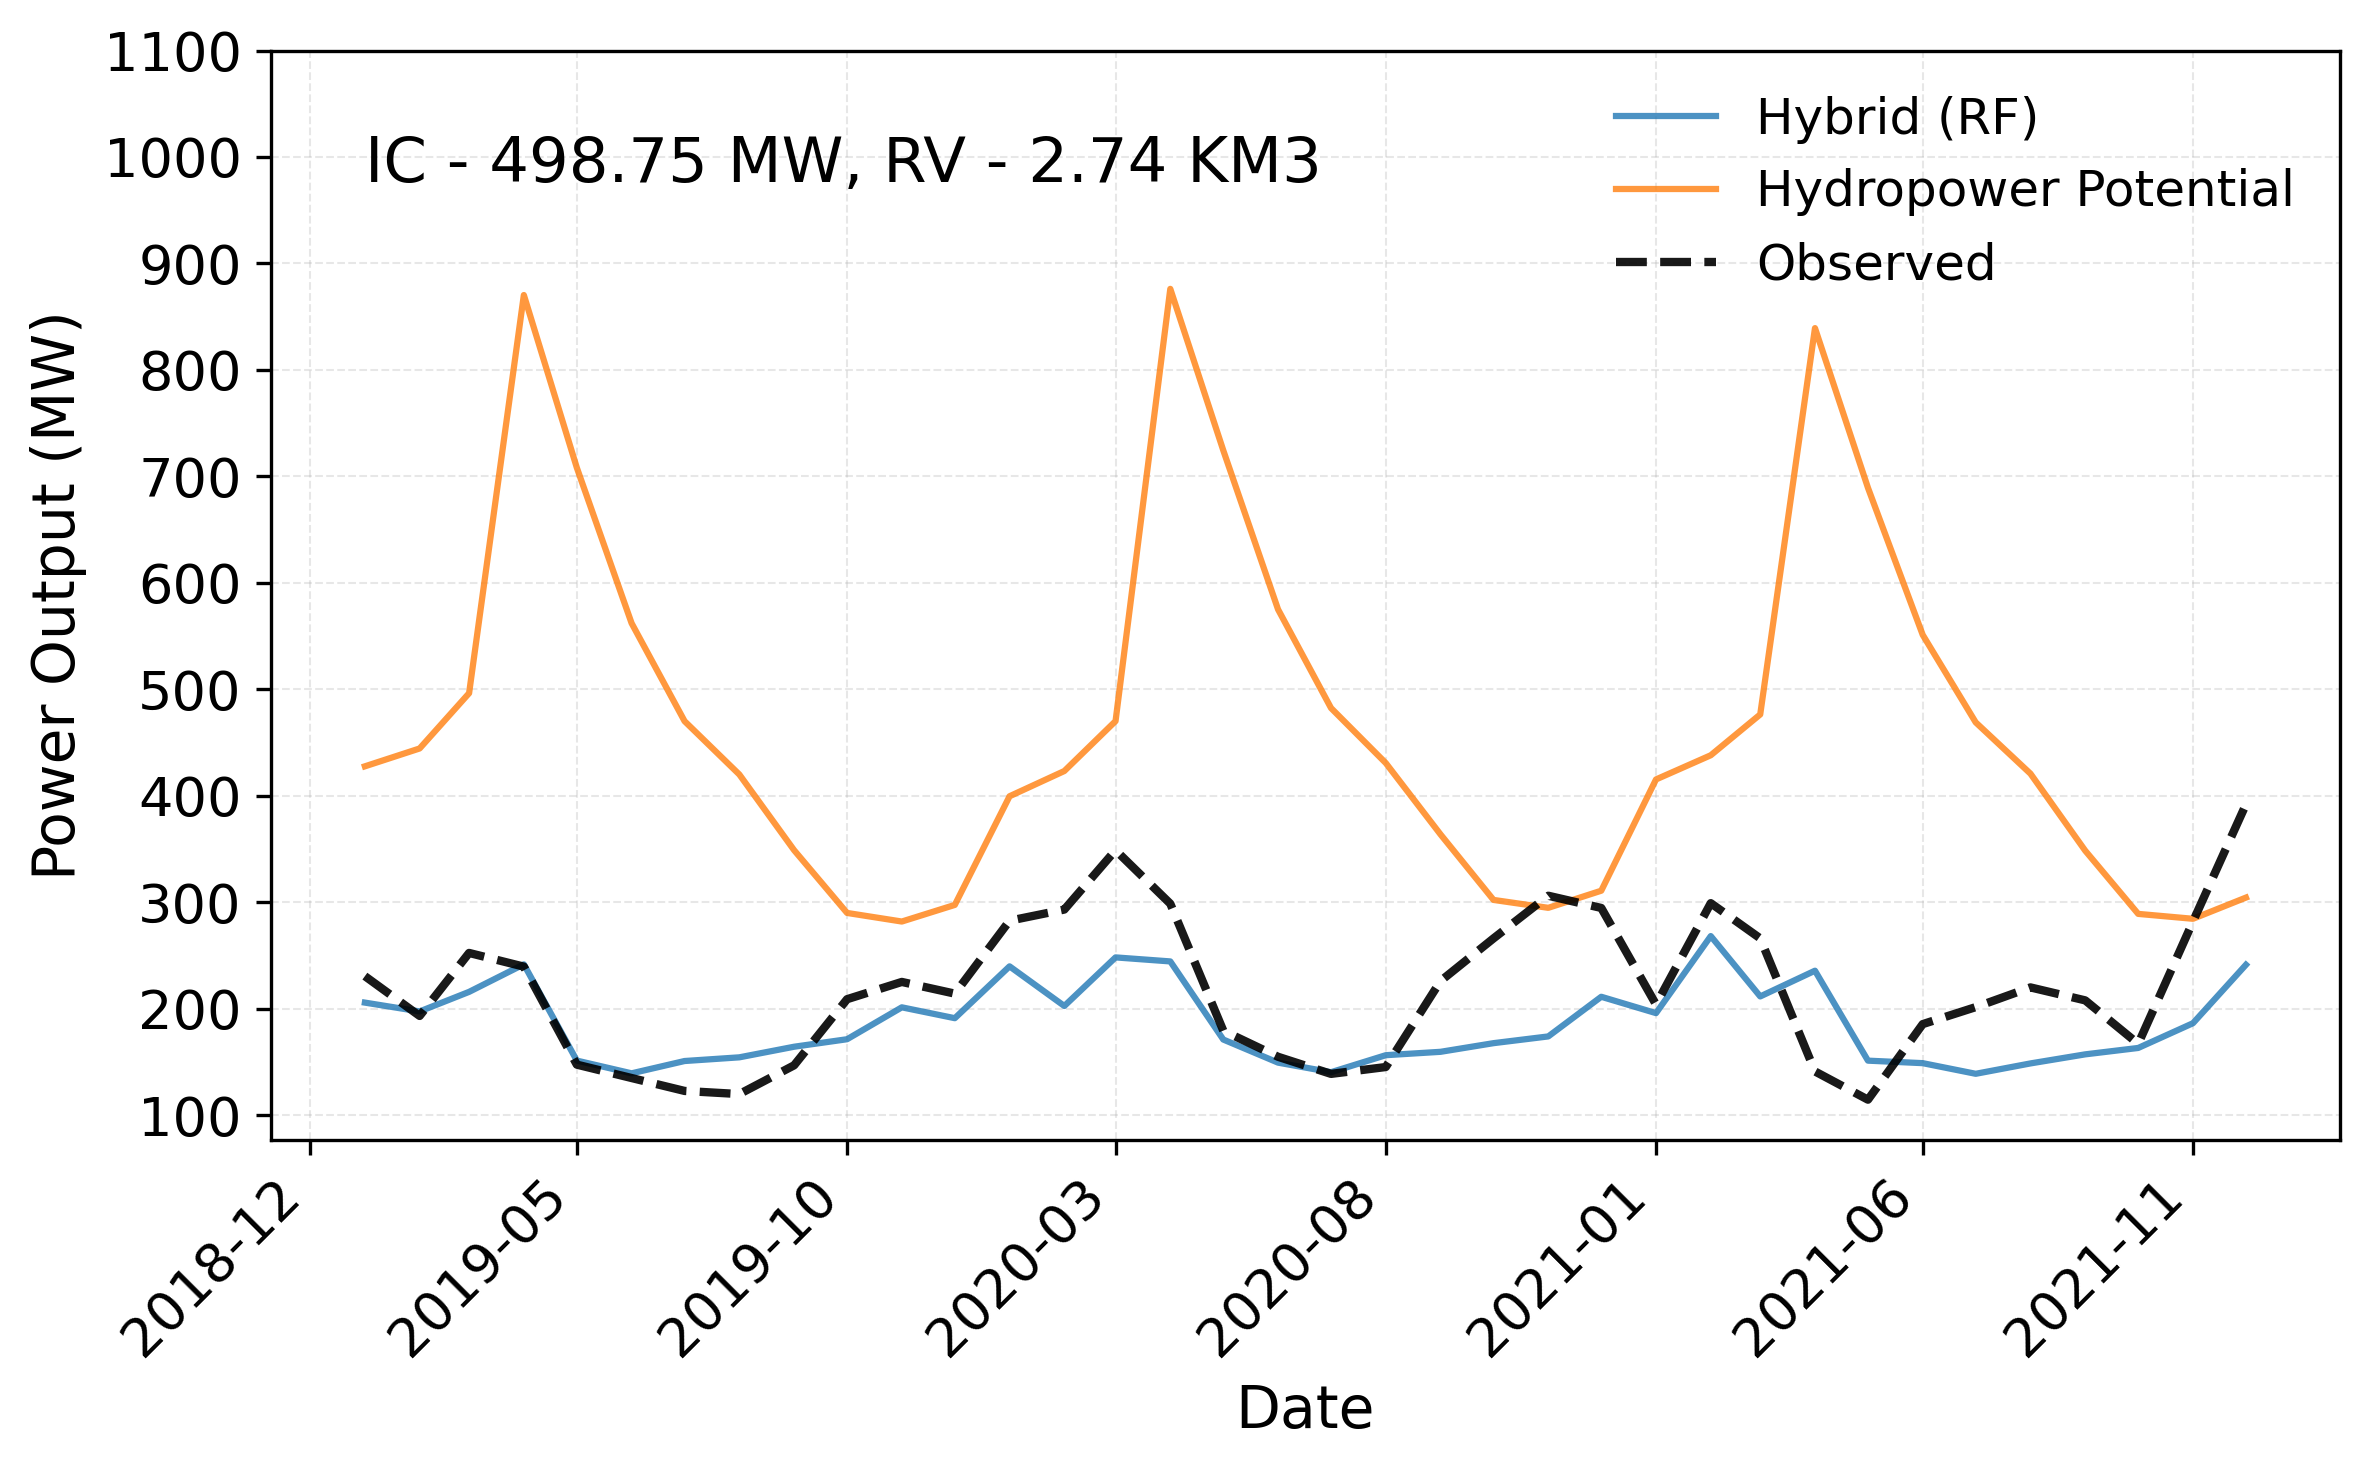

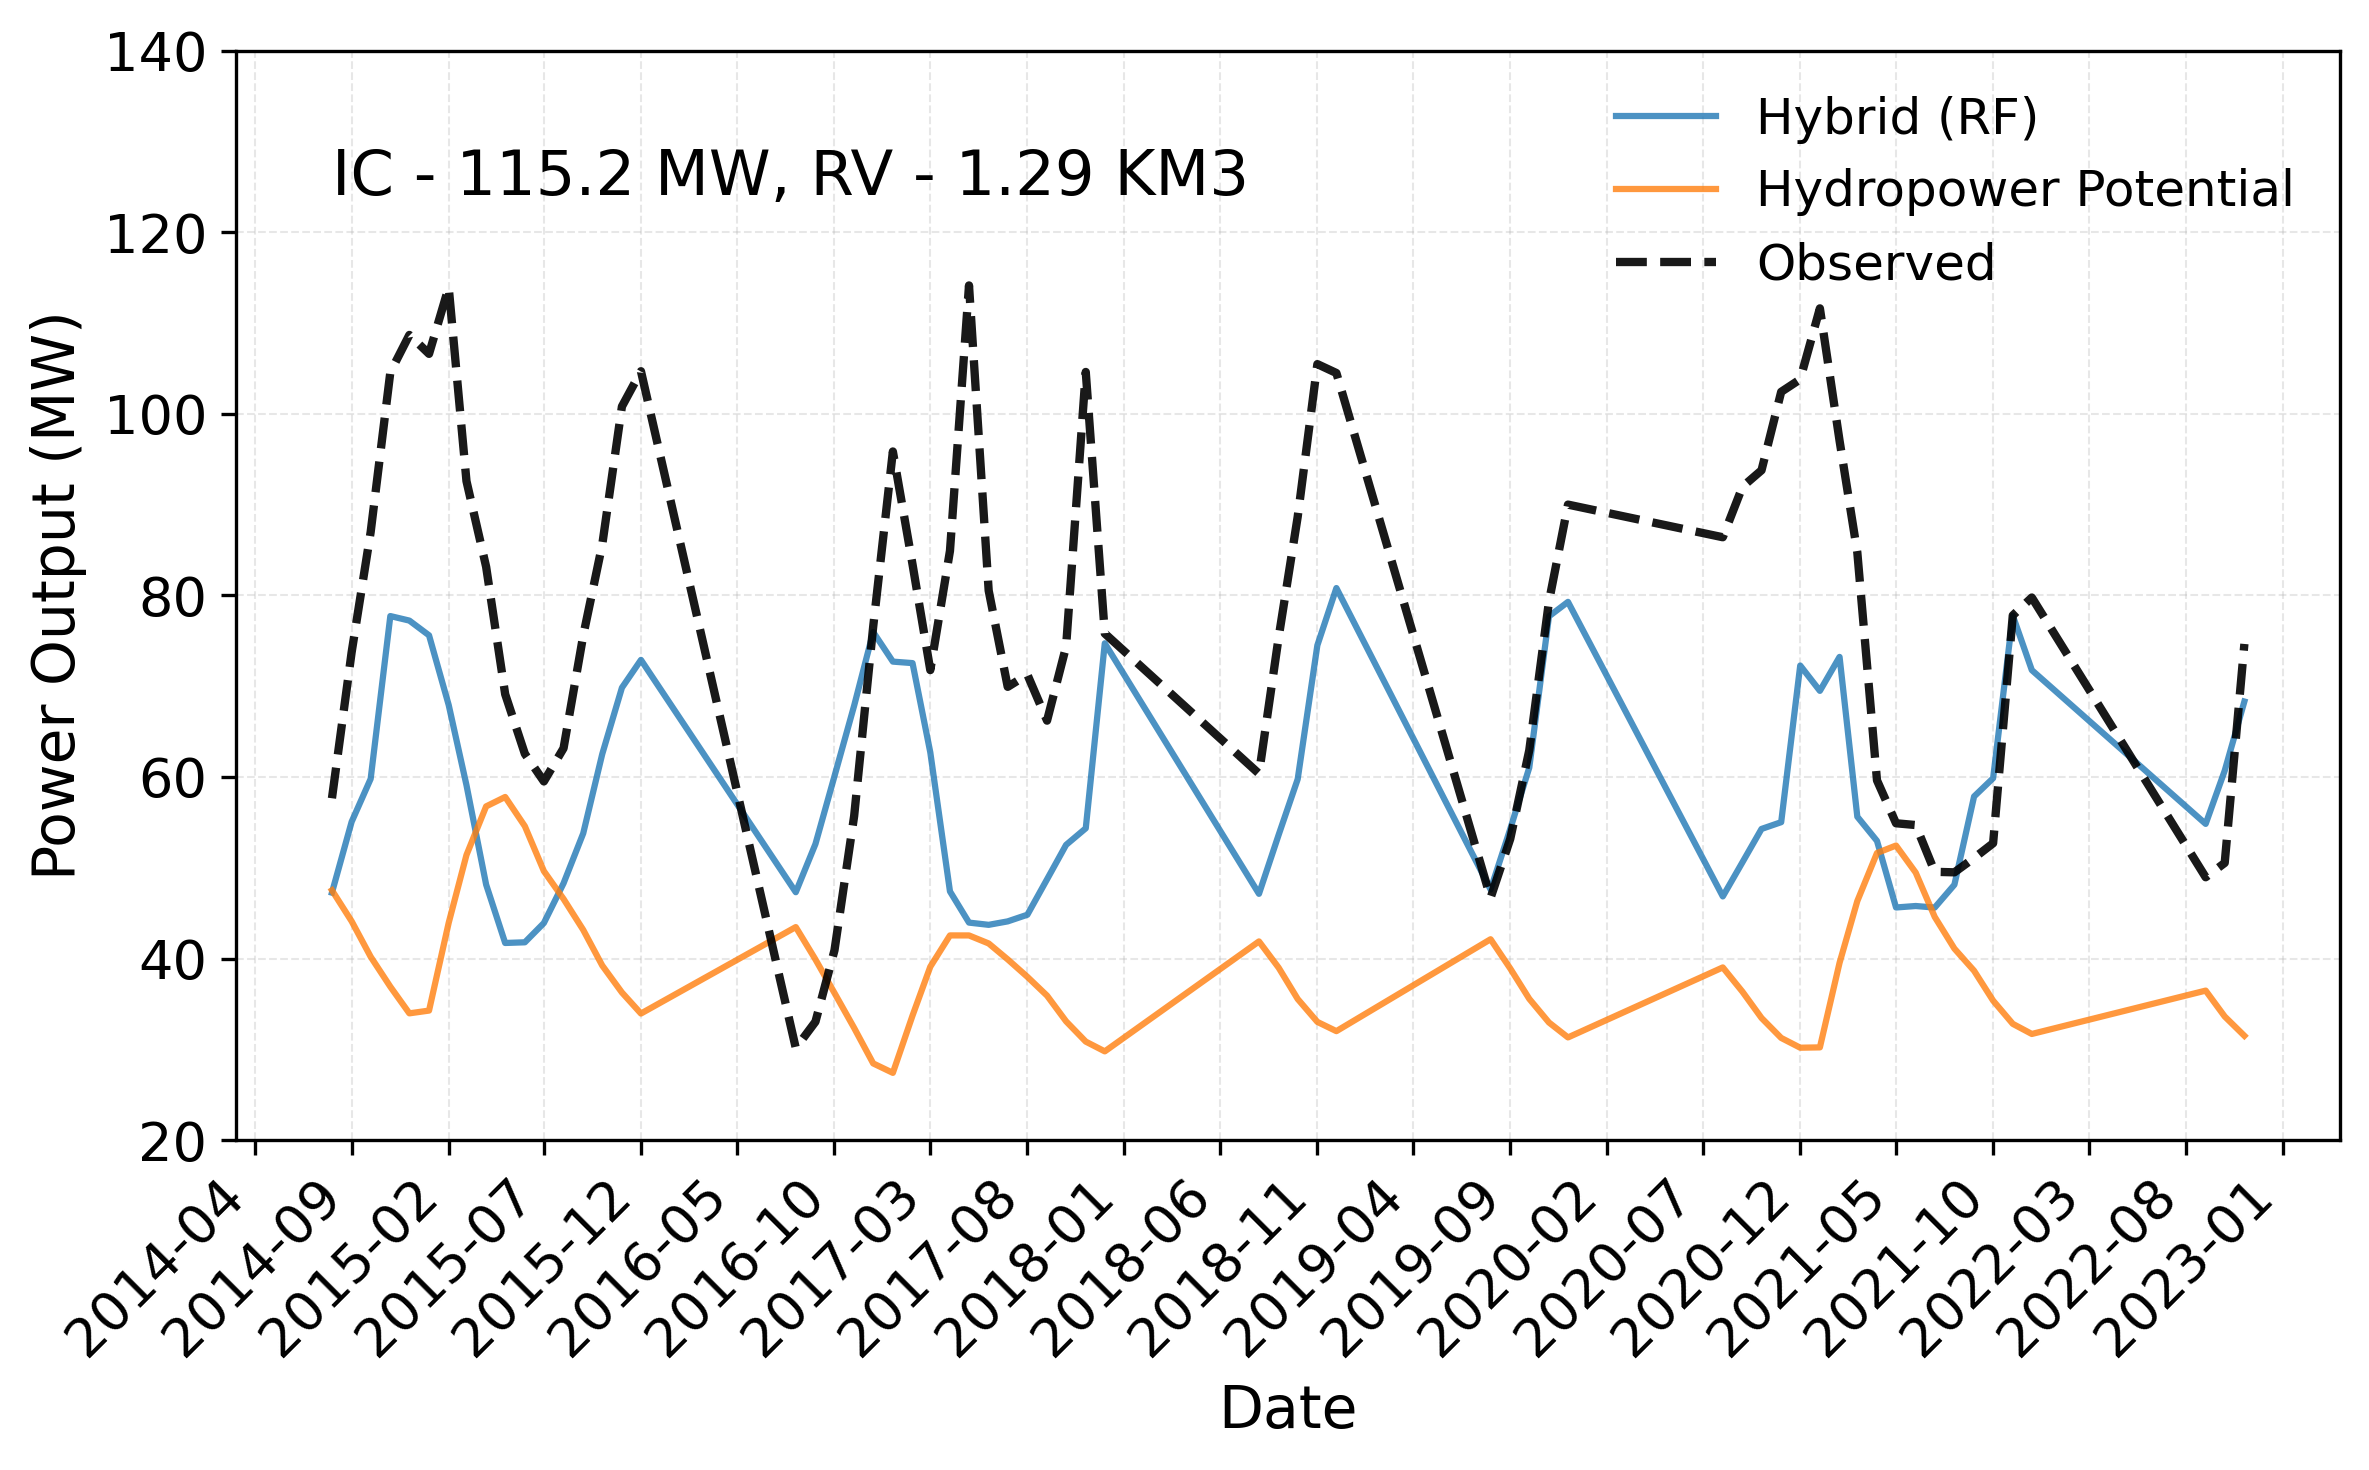

In [30]:
timeseries_plot(plant_ID = "GHR00749", text_limit = 100,  lower_range_yticks = 100, upper_range_yticks =  1200, diff = 100)
timeseries_plot(plant_ID = "GHR06780", text_limit  = 10,  lower_range_yticks = 20, upper_range_yticks =  160, diff = 20)
